### Renders 3D density plots of subhalos

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, Normalize, LogNorm
import h5py
import time
import os
import astropy.units as u
import astropy.cosmology.units as cu
import astropy.constants as const
import raytrace

with h5py.File("outputs/dm_proto.hdf5", "r") as f:
    halo_ids = list(f.keys())
list(enumerate(halo_ids))

halo_id = halo_ids[10][5:]
halo_id

with h5py.File("outputs/dm_proto.hdf5", "r") as f:
    halo = f['halo_' + halo_id]
    print(halo.keys())
    print(halo['GroupMassType'][:])
    com = halo['GroupCM'][:]
    r500 = halo['Group_R_Crit500'][()]
    subhalo_id = halo['subhalos']["id"][:]

with h5py.File(f'tng_cache/snap_099/cutout_{halo_id}.hdf5', 'r') as f:
    gas_mass = f['PartType0/Masses'][:] * ((1e10 * u.solMass).to(u.kg) / cu.littleh) # kg ckpc^-3
    gas_density = f['PartType0/Density'][:] * (1e10 * u.solMass).to(u.kg) / cu.littleh / ( u.kpc / cu.littleh)**3 # kg ckpc^-3
    gas_volume = gas_mass/gas_density
    gas_radius = ((0.75/np.pi)*gas_volume)**(1/3)
    gas_electron_abundance = f['PartType0/ElectronAbundance'][:] # fraction
    gas_hydrogen_massfrac = f['PartType0/GFM_Metals'][:,0] # fraction
    gas_sfr = f['PartType0/StarFormationRate'][:] # Msun/year
    
    gas_pos = raytrace.unwrap(f['PartType0/Coordinates'][:] - com) # ckpc
    gas_id = f['PartType0/ParticleIDs'][:] # id
    gas_subhalo_id = f['PartType0/SubhaloIDs'][:] # id
    gas_sfr = f['PartType0/StarFormationRate'][:] # Msun/yr
    gas_n_e = (gas_density * gas_electron_abundance * gas_hydrogen_massfrac / const.m_p).value # ckpc^-3
    gas_N_e = (gas_mass * gas_electron_abundance * gas_hydrogen_massfrac / const.m_p).value # ckpc^-3
    
    star_select = f['PartType4/GFM_StellarFormationTime'][:] > 0 # bool
    star_id = f['PartType4/ParticleIDs'][star_select] # id
    star_subhalo_id = f['PartType4/SubhaloIDs'][star_select] # id
    star_pos = raytrace.unwrap(f['PartType4/Coordinates'][star_select] - com) # ckpc
    star_mass = f['PartType4/Masses'][star_select] * (1e10 * u.solMass).to(u.kg).value # kg


In [52]:
# center gas cell
# new_com = gas_pos[np.argmax(gas_sfr)]
# gas_pos -= new_com

In [8]:
cmaps = ['spring', 'summer', 'autumn', 'winter', 'cool', 'Wistia']

In [54]:
fade_cmaps = list()
for cmap in cmaps:
    x = plt.get_cmap(cmap+'_r')
    fade_x = x(np.arange(x.N))
    fade_x[:, -1] = np.linspace(0, 1, x.N) # modify alpha
    fade_cmaps.append(ListedColormap(fade_x))

In [55]:
X = 1
Y = 2
Z = 0
xspan = np.max(gas_pos[:, X]) - np.min(gas_pos[:, X])
yspan = np.max(gas_pos[:, Y]) - np.min(gas_pos[:, Y])
zspan = np.max(gas_pos[:, Z]) - np.min(gas_pos[:, Z])
bins = 100
y0 = np.max([xspan, yspan, zspan])
edges = np.linspace(-0.5, 0.5, bins)
xspan, yspan, zspan, y0

(np.float64(5862.154777301883),
 np.float64(4806.137953037571),
 np.float64(6038.596363272867),
 np.float64(6038.596363272867))

In [56]:
outpath = f'vis/halo_{halo_id}'
if not os.path.isdir(outpath):
   os.makedirs(outpath)

#### Subhalos with different colors

#### Subhalos by SFR

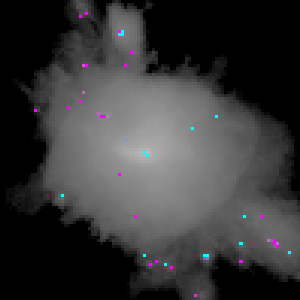

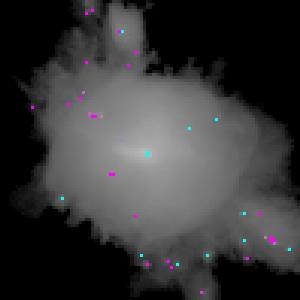

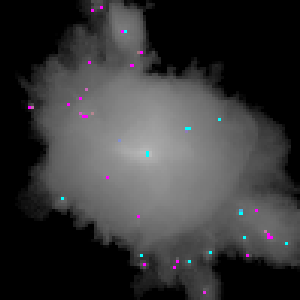

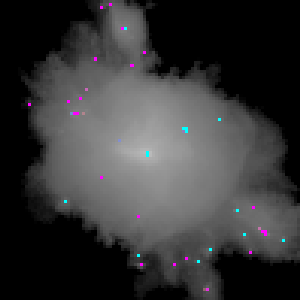

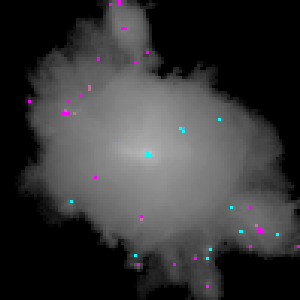

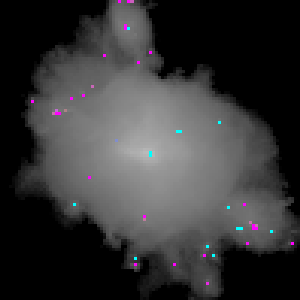

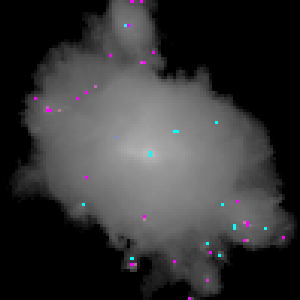

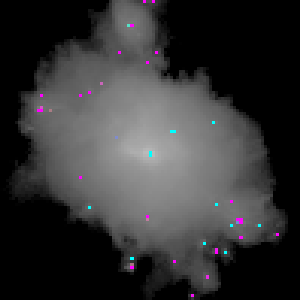

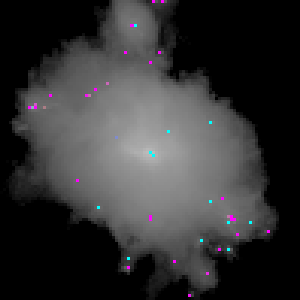

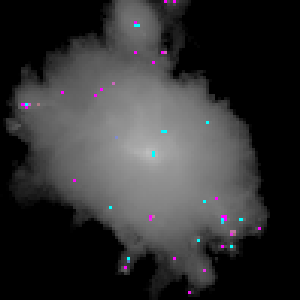

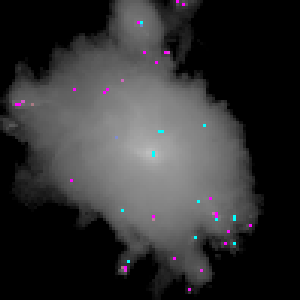

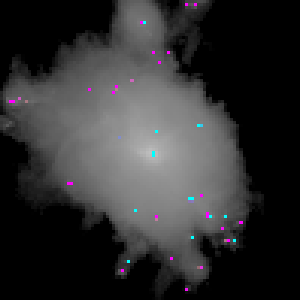

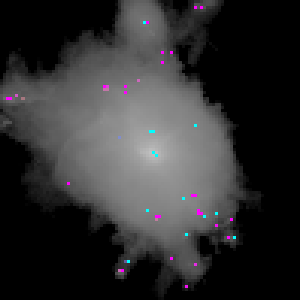

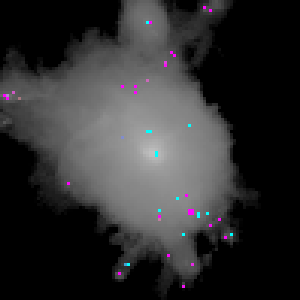

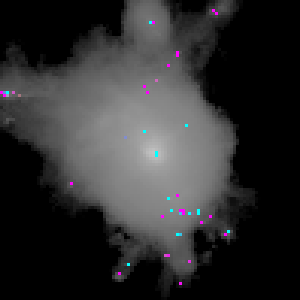

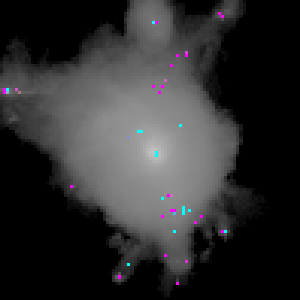

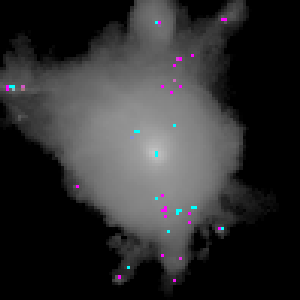

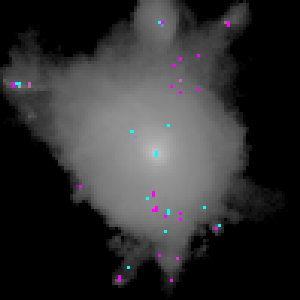

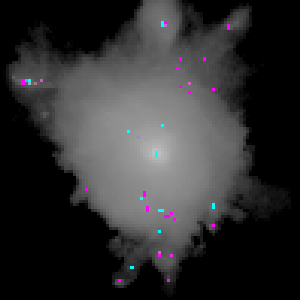

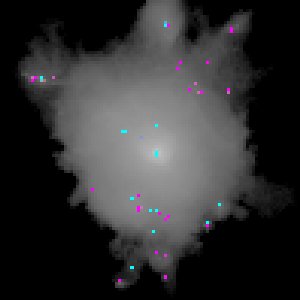

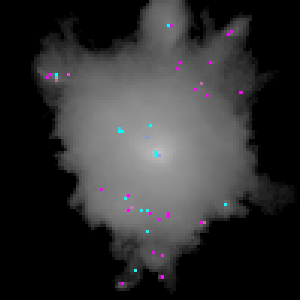

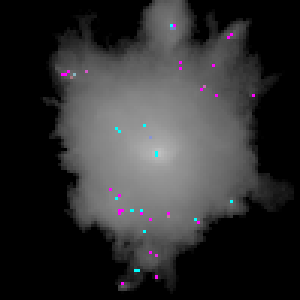

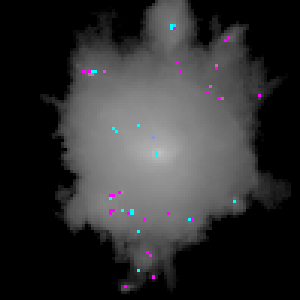

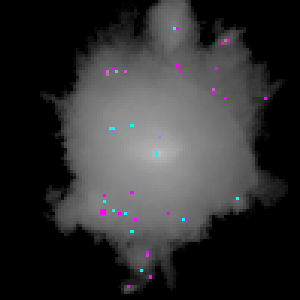

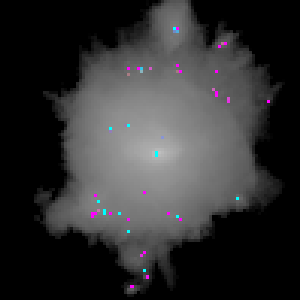

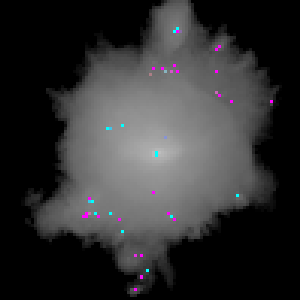

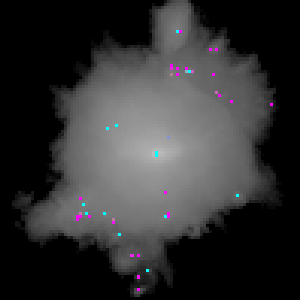

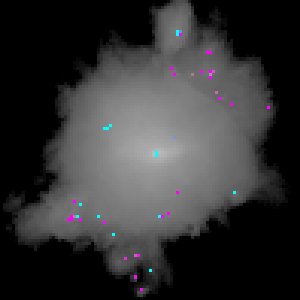

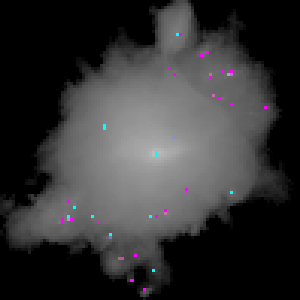

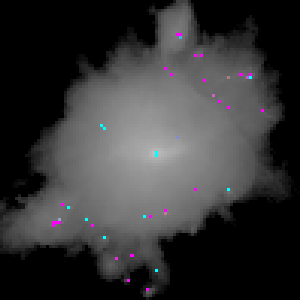

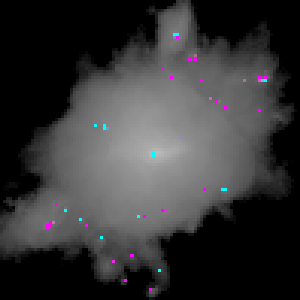

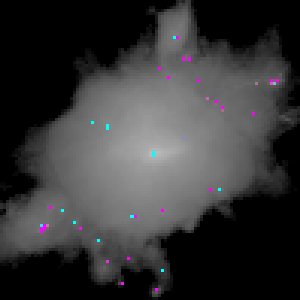

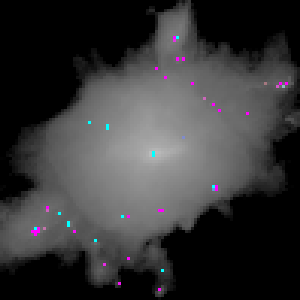

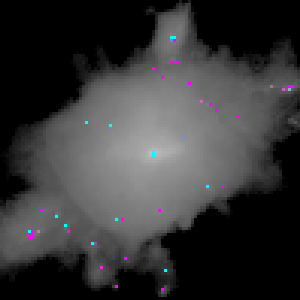

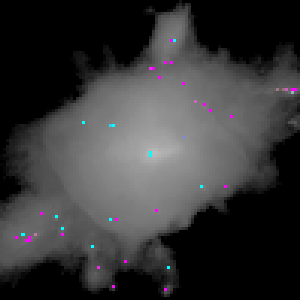

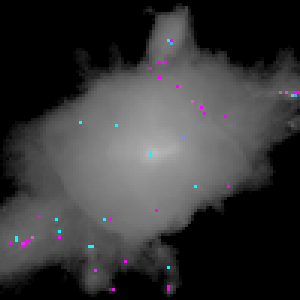

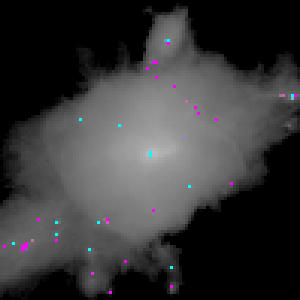

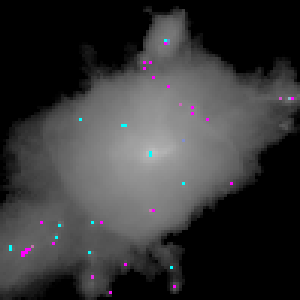

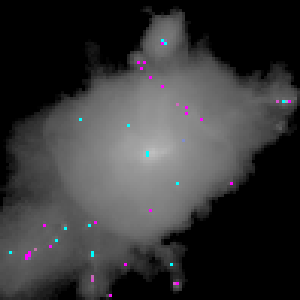

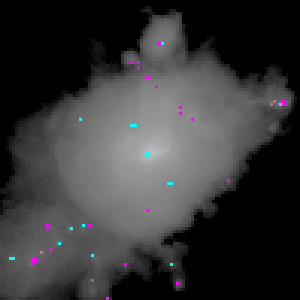

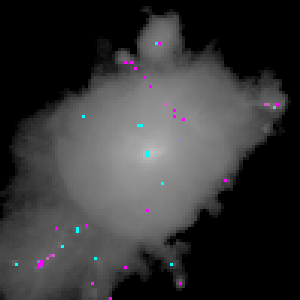

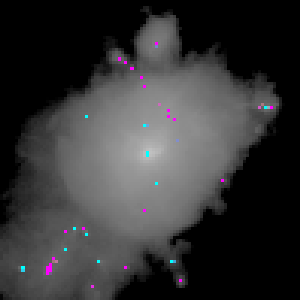

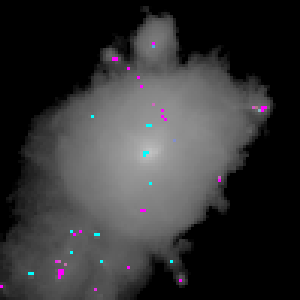

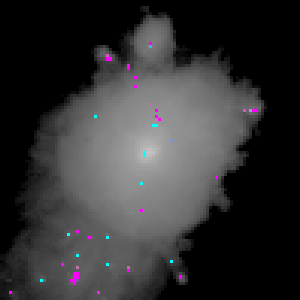

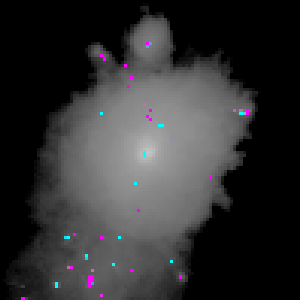

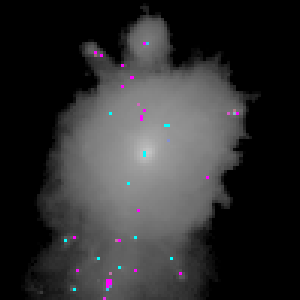

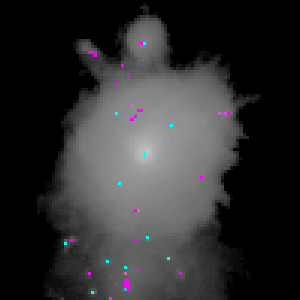

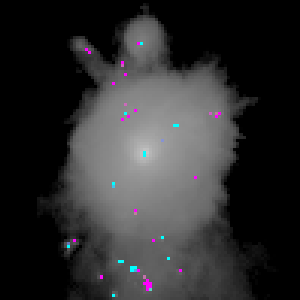

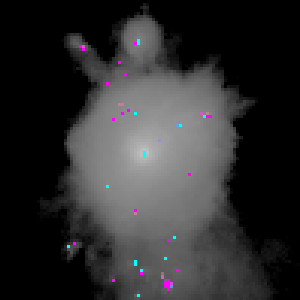

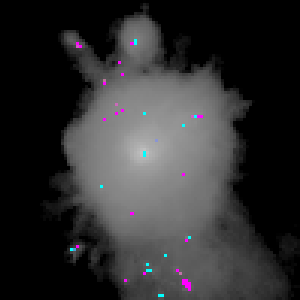

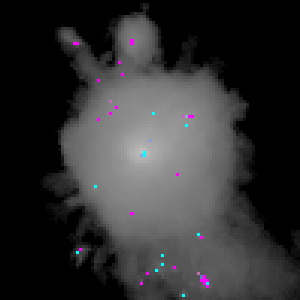

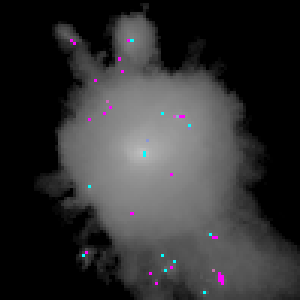

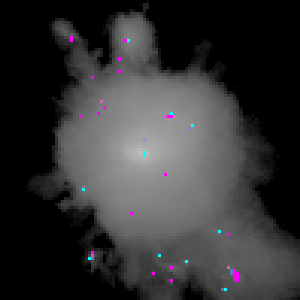

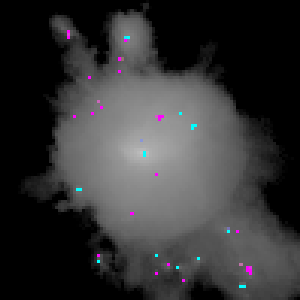

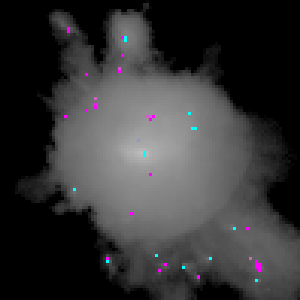

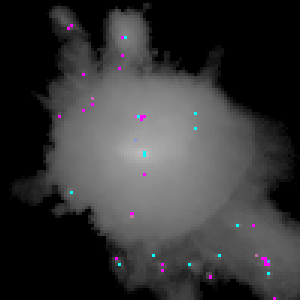

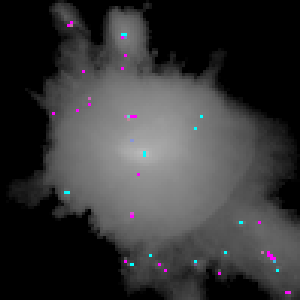

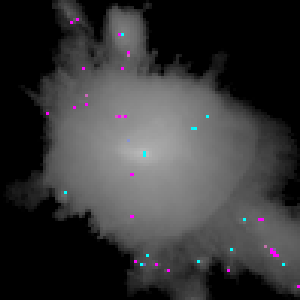

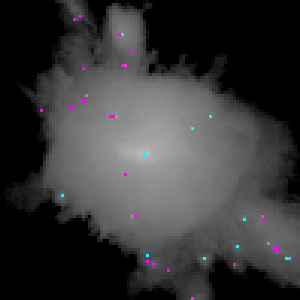

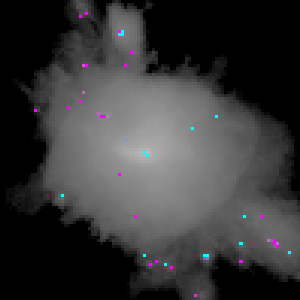

In [62]:
for (i, theta) in enumerate(np.linspace(0, 2*np.pi, 60)):
    fig, ax = plt.subplots(1,1, figsize=(100, 100), dpi=3, facecolor='black', constrained_layout=True)
    cos = np.cos(theta)
    sin = np.sin(theta)
    y = sin*gas_pos[:, X] + cos*gas_pos[:, Y] + y0
    plt.axis('off')
    plt.hist2d(
        x=(cos*gas_pos[:, X] - sin*gas_pos[:, Y])/y, 
        y=(gas_pos[:, Z])/y, 
        bins=(edges, edges), 
        weights=gas_mass.value,
        cmap='Greys_r',
        norm=LogNorm(vmin=1e38, vmax=1e45),
    )

    # y = sin*star_pos[:, X] + cos*star_pos[:, Y] + y0
    # plt.hist2d(
    #     x=(cos*star_pos[:, X] - sin*star_pos[:, Y])/y, 
    #     y=star_pos[:, Z]/y, 
    #     bins=(edges, edges),
    #     norm=LogNorm(vmin=1e37, vmax=1e41),
    #     weights=star_mass[:], 
    #     cmap=fade_cmaps[2],
    # )
    
    
    plt.hist2d(
        x=(cos*gas_pos[:, X] - sin*gas_pos[:, Y])/y, 
        y=(gas_pos[:, Z])/y, 
        bins=(edges, edges), 
        weights=gas_sfr,
        cmap=fade_cmaps[4],
        norm=LogNorm(vmin=1e-3, vmax=1e-1),
    )

    select = gas_subhalo_id == -1
    y = sin*gas_pos[select, X] + cos*gas_pos[select, Y] + y0

    plt.hist2d(
        x=(cos*gas_pos[select, X] - sin*gas_pos[select, Y])/y, 
        y=(gas_pos[select, Z])/y, 
        bins=(edges, edges), 
        weights=gas_sfr[select],
        cmap=fade_cmaps[0],
        norm=LogNorm(vmin=1e-3, vmax=1e-1),
    )
    
    plt.savefig(f'{outpath}/sfr_{i:02}.png')
    plt.show()
    plt.clf()
    plt.close('all')

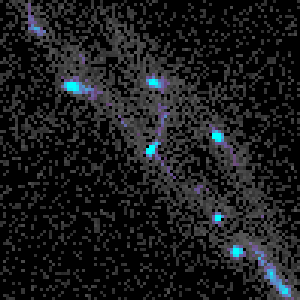

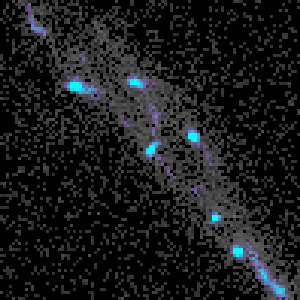

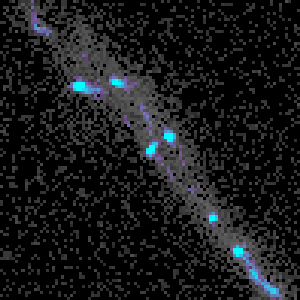

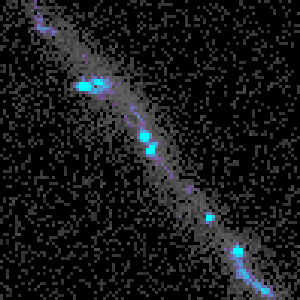

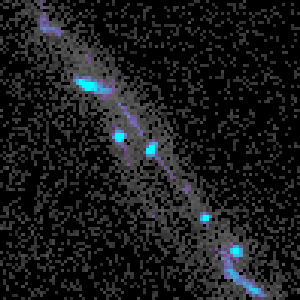

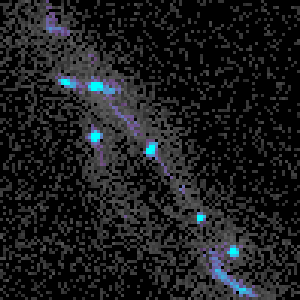

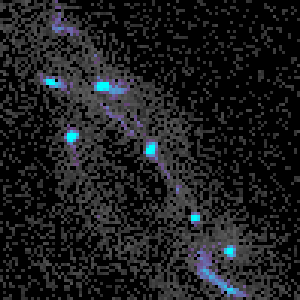

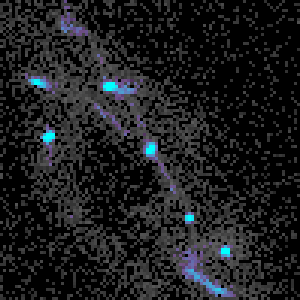

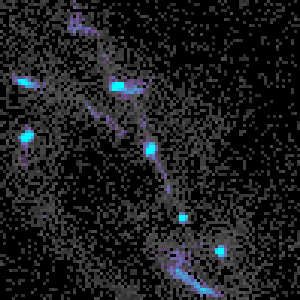

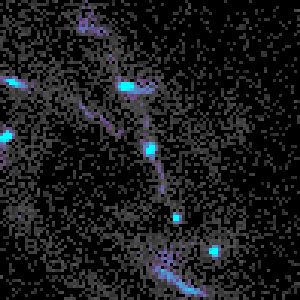

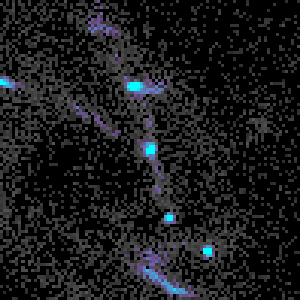


KeyboardInterrupt



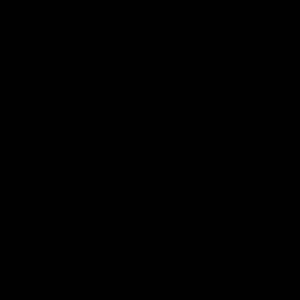

In [12]:
for (i, theta) in enumerate(np.linspace(0, 2*np.pi, 60)):
    fig, ax = plt.subplots(1,1, figsize=(100, 100), dpi=3, facecolor='black', constrained_layout=True)
    cos = np.cos(theta)
    sin = np.sin(theta)
    y = sin*gas_pos[:, X] + cos*gas_pos[:, Y] + y0
    y /= 100
    plt.axis('off')
    plt.hist2d(
        x=(cos*gas_pos[:, X] - sin*gas_pos[:, Y])/y, 
        y=(gas_pos[:, Z])/y, 
        bins=(edges, edges), 
        weights=gas_mass.value,
        cmap='Greys_r',
        norm=LogNorm(vmin=1e36, vmax=1e43),
    )
    plt.hist2d(
        x=(cos*gas_pos[:, X] - sin*gas_pos[:, Y])/y, 
        y=(gas_pos[:, Z])/y, 
        bins=(edges, edges), 
        weights=gas_sfr,
        cmap=fade_cmaps[4],
        norm=LogNorm(vmin=1e-3, vmax=1e-1),
    )
    
    plt.savefig(f'{outpath}/sfr_zoom_{i:02}.png')
    plt.show()
    plt.clf()
    plt.close('all')

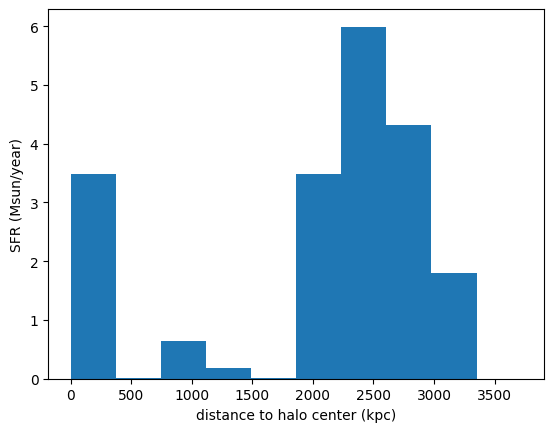

In [58]:
select = gas_subhalo_id != -1
plt.hist(np.linalg.norm(gas_pos[select], axis=-1), weights=gas_sfr[select], bins=10)
plt.xlabel('distance to halo center (kpc)')
plt.ylabel('SFR (Msun/year)')
plt.show()

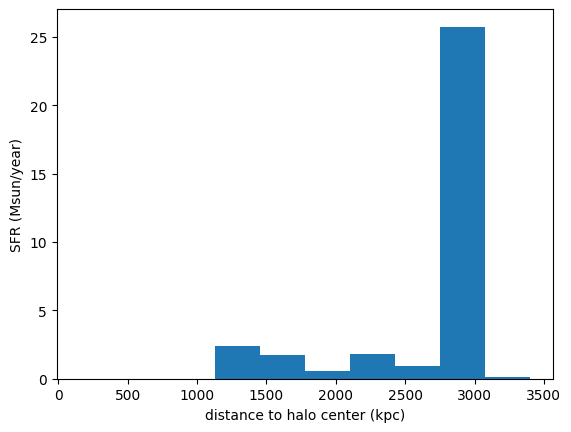

In [59]:
select = gas_subhalo_id == -1
plt.hist(np.linalg.norm(gas_pos[select], axis=-1), weights=gas_sfr[select], bins=10)
plt.xlabel('distance to halo center (kpc)')
plt.ylabel('SFR (Msun/year)')
plt.show()

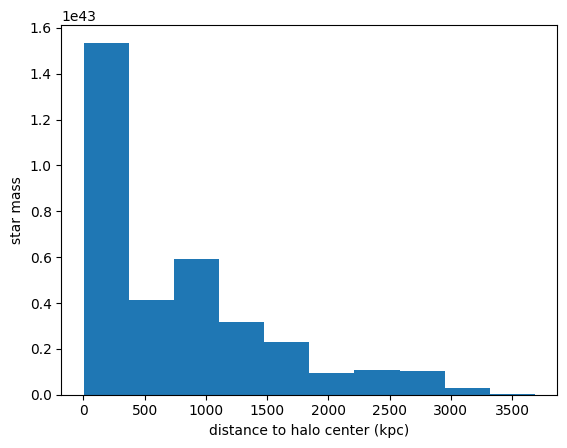

In [60]:
plt.hist(np.linalg.norm(star_pos[:], axis=-1), weights=star_mass[:], bins=10)
plt.xlabel('distance to halo center (kpc)')
plt.ylabel('star mass')
plt.show()

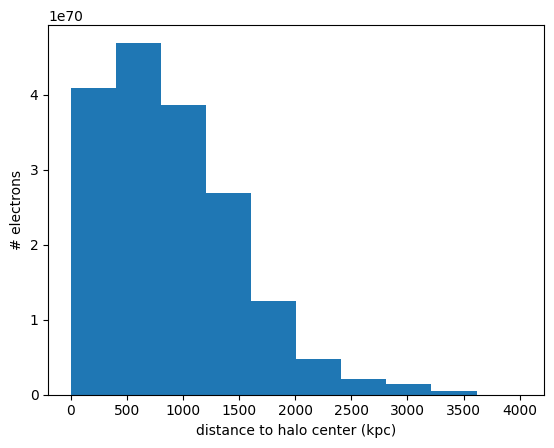

In [45]:
plt.hist(np.linalg.norm(gas_pos[:], axis=-1), weights=gas_N_e, bins=10)
plt.xlabel('distance to halo center (kpc)')
plt.ylabel('# electrons')
plt.show()

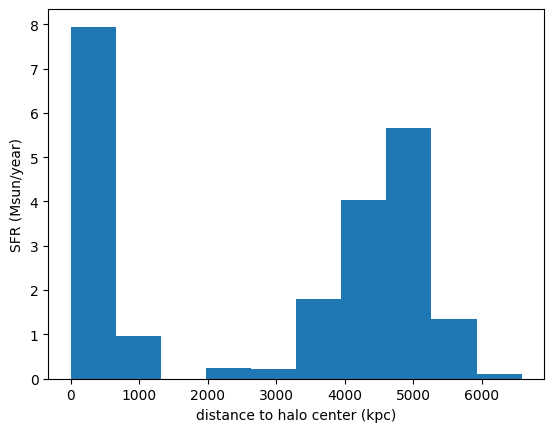

In [56]:
plt.hist(np.linalg.norm(gas_pos[:], axis=-1), weights=gas_sfr, bins=10)
plt.xlabel('distance to halo center (kpc)')
plt.ylabel('SFR (Msun/year)')
plt.show()

In [ ]:
print(np.max(gas_sfr))
plt.hist(np.log10(gas_sfr[gas_sfr>1e-5]))
plt.gca().set_yscale('log')
plt.show()

In [59]:
cm_kpc = u.cm.to(u.kpc)
cm_kpc

3.2407792894443653e-22